#                                  TP:1
## Apprentissage supervisé avec Scikit-learn


Exercice 1 — Régression : Prédiction du tarif d’un trajet Uber

In [36]:
import pandas as pd 

data=pd.read_csv('uber.csv')

data.head(10)


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
5,44470845,2011-02-12 02:27:09.0000006,4.9,2011-02-12 02:27:09 UTC,-73.969019,40.755910,-73.969019,40.755910,1
6,48725865,2014-10-12 07:04:00.0000002,24.5,2014-10-12 07:04:00 UTC,-73.961447,40.693965,-73.871195,40.774297,5
7,44195482,2012-12-11 13:52:00.00000029,2.5,2012-12-11 13:52:00 UTC,0.000000,0.000000,0.000000,0.000000,1
8,15822268,2012-02-17 09:32:00.00000043,9.7,2012-02-17 09:32:00 UTC,-73.975187,40.745767,-74.002720,40.743537,1
9,50611056,2012-03-29 19:06:00.000000273,12.5,2012-03-29 19:06:00 UTC,-74.001065,40.741787,-73.963040,40.775012,1


In [37]:
data.info()
data.shape

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  str    
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  str    
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), str(2)
memory usage: 13.7 MB


(200000, 9)

In [38]:
data.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [39]:
data.dropna(inplace=True)

In [40]:
data['fare_amount']=data['fare_amount'].abs()

In [41]:
data['pickup_datetime']=pd.to_datetime(data['pickup_datetime'])

In [42]:
data['hour']=data['pickup_datetime'].dt.hour

In [43]:
data['day_of_week']=data['pickup_datetime'].dt.day_of_week

In [44]:
data.head(10)

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day_of_week
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,19,3
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,20,4
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,21,0
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,8,4
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,17,3
5,44470845,2011-02-12 02:27:09.0000006,4.9,2011-02-12 02:27:09+00:00,-73.969019,40.755910,-73.969019,40.755910,1,2,5
6,48725865,2014-10-12 07:04:00.0000002,24.5,2014-10-12 07:04:00+00:00,-73.961447,40.693965,-73.871195,40.774297,5,7,6
7,44195482,2012-12-11 13:52:00.00000029,2.5,2012-12-11 13:52:00+00:00,0.000000,0.000000,0.000000,0.000000,1,13,1
8,15822268,2012-02-17 09:32:00.00000043,9.7,2012-02-17 09:32:00+00:00,-73.975187,40.745767,-74.002720,40.743537,1,9,4
9,50611056,2012-03-29 19:06:00.000000273,12.5,2012-03-29 19:06:00+00:00,-74.001065,40.741787,-73.963040,40.775012,1,19,3


In [45]:
data[(data['pickup_latitude']<=-90)|(data['dropoff_latitude']>=90)|(data['pickup_latitude']>=90)|(data['dropoff_latitude']<=-90)]

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day_of_week
56617,14257861,2012-03-11 07:24:00.00000031,8.1,2012-03-11 07:24:00+00:00,-73.960828,404.433332,-73.988357,40.769037,1,7,6
61793,2849369,2012-06-13 05:45:00.0000006,8.5,2012-06-13 05:45:00+00:00,-73.951385,401.066667,-73.982110,40.754117,1,5,2
75851,33249845,2011-11-05 00:22:00.00000051,15.7,2011-11-05 00:22:00+00:00,-1340.648410,1644.421482,-3356.666300,872.697628,1,0,5
91422,23566642,2011-05-18 13:24:00.000000213,16.1,2011-05-18 13:24:00+00:00,57.418457,1292.016128,1153.572603,-881.985513,1,13,2
139447,39981694,2012-01-20 11:50:00.00000088,13.7,2012-01-20 11:50:00+00:00,-74.011042,40.709780,-73.983163,493.533332,4,11,4


In [46]:
data[(data['pickup_longitude']<=-180)|(data['dropoff_longitude']>=180)|(data['pickup_longitude']>=180)|(data['dropoff_longitude']<=-180)]

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day_of_week
4949,42931506,2012-04-28 00:58:00.000000235,4.9,2012-04-28 00:58:00+00:00,-748.016667,40.739957,-74.003570,40.734192,1,0,5
32549,5634081,2012-06-16 10:04:00.00000061,15.7,2012-06-16 10:04:00+00:00,-74.016055,40.715155,-737.916665,40.697862,2,10,5
48506,1055960,2011-11-05 23:26:00.000000309,33.7,2011-11-05 23:26:00+00:00,-735.200000,40.770092,-73.980187,40.765530,1,23,5
75851,33249845,2011-11-05 00:22:00.00000051,15.7,2011-11-05 00:22:00+00:00,-1340.648410,1644.421482,-3356.666300,872.697628,1,0,5
91422,23566642,2011-05-18 13:24:00.000000213,16.1,2011-05-18 13:24:00+00:00,57.418457,1292.016128,1153.572603,-881.985513,1,13,2
103745,16826862,2011-10-14 19:04:00.000000202,12.9,2011-10-14 19:04:00+00:00,-736.216667,40.767035,-73.982377,40.725562,1,19,4
144253,9421322,2009-08-26 11:55:00.00000023,7.3,2009-08-26 11:55:00+00:00,-768.550000,40.757812,-73.997040,40.740007,1,11,2
161652,25264921,2010-05-12 12:19:00.00000098,4.1,2010-05-12 12:19:00+00:00,-735.433332,40.740605,-74.006373,40.739607,1,12,2
199936,44787414,2012-07-21 16:19:00.00000099,4.1,2012-07-21 16:19:00+00:00,-736.400000,40.774307,-73.982215,40.769672,5,16,5


avant de calcule la distance on suprimer les valeure aberant de latitue et de longitude

In [47]:
data = data[
    (data['pickup_latitude']<=90) & (data['pickup_latitude']>=-90) &
    (data['dropoff_latitude']<=90) & (data['dropoff_latitude']>=-90) &
    (data['pickup_longitude']<180) & (data['pickup_longitude']>=-180) &
    (data['dropoff_longitude']<180) &(data['dropoff_longitude']>=-180)
]



### Calcule  de la distance entre les point 

In [48]:
import numpy as np

R = 6371.0
lat1 = np.radians(data['pickup_latitude'])
lon1 = np.radians(data['pickup_longitude'])

lat2 = np.radians(data['dropoff_latitude'])
lon2 = np.radians(data['dropoff_longitude'])

dphi = lat2 - lat1
dlambda = lon2 - lon1

lat_moyenne = (lat1 + lat2) / 2.0

x = dlambda* np.cos(lat_moyenne)
y = dphi

data['distance_km'] = R * np.sqrt(x**2 + y**2)

In [49]:
# on supriment les distance null
data=data[data['distance_km']!=0]

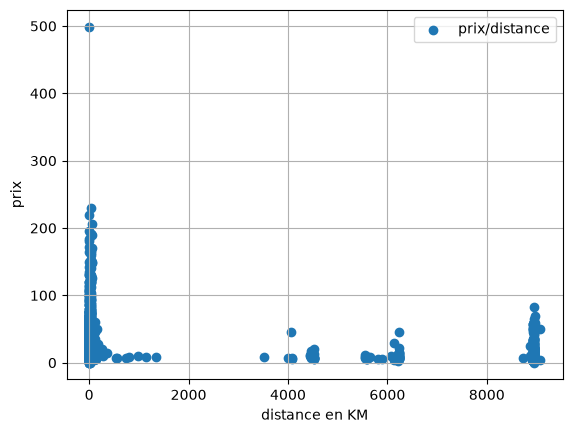

In [50]:
import matplotlib.pyplot as plt


plt.scatter(data['distance_km'],data['fare_amount'],label='prix/distance')
plt.xlabel(f'distance en KM')
plt.ylabel('prix')
plt.grid(True)
plt.legend()
plt.show()

In [51]:
data[
    (data['pickup_latitude'] == 0) |
    (data['pickup_longitude'] == 0) |
    (data['dropoff_latitude'] == 0) |
    (data['dropoff_longitude'] == 0)
]

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day_of_week,distance_km
346,25741482,2015-03-05 19:15:07.0000001,15.50,2015-03-05 19:15:07+00:00,0.000000,0.000000,-73.979805,40.786030,1,19,3,8945.466514
1067,10614181,2014-02-02 22:27:00.000000234,52.00,2014-02-02 22:27:00+00:00,-73.781095,40.645015,0.000000,0.000000,1,22,6,8922.693853
1526,16419344,2014-05-12 12:00:15.0000002,2.50,2014-05-12 12:00:15+00:00,-74.001849,40.715156,0.000000,0.000000,3,12,0,8944.983188
2547,1227592,2011-09-20 21:08:00.00000037,10.10,2011-09-20 21:08:00+00:00,0.000000,0.000000,-73.953210,40.803528,2,21,1,8943.687095
3045,2267128,2013-03-26 02:25:17.0000001,15.00,2013-03-26 02:25:17+00:00,0.000000,0.000000,-73.843777,40.739255,1,2,1,8931.615534
...,...,...,...,...,...,...,...,...,...,...,...,...
196967,35583841,2014-09-17 09:40:30.0000003,57.33,2014-09-17 09:40:30+00:00,0.000000,0.000000,-73.789045,40.655135,2,9,2,8923.761611
197468,45145191,2011-02-23 19:42:00.000000141,6.90,2011-02-23 19:42:00+00:00,0.000000,0.000000,-73.980827,40.747133,5,19,2,8944.204890
197863,54381864,2014-11-18 22:10:03.0000001,7.00,2014-11-18 22:10:03+00:00,-73.962190,40.759158,0.000000,0.000000,1,22,1,8942.948447
198567,29279997,2013-10-21 01:28:00.00000010,23.50,2013-10-21 01:28:00+00:00,-73.968115,40.801455,0.000000,0.000000,2,1,0,8944.953582


en suprime les cordoner dans le longitude et latitude egala 0

In [52]:
data=data[
        (data['pickup_latitude'] != 0) &
    (data['pickup_longitude'] != 0) &
    (data['dropoff_latitude'] != 0) &
    (data['dropoff_longitude'] != 0)
]
    


In [53]:
data=data[(data['distance_km']<60)]

In [54]:
#supriment les distance inf a 1 km
data=data[(data['distance_km']>0.9)]

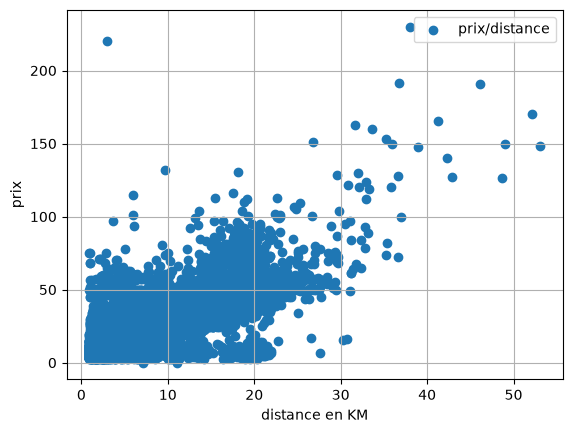

In [55]:
plt.scatter(data['distance_km'],data['fare_amount'],label='prix/distance')
plt.xlabel(f'distance en KM')
plt.ylabel('prix')
plt.grid(True)
plt.legend()
plt.show()

In [56]:
data[data['fare_amount']>200]

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day_of_week,distance_km
29261,5471406,2013-09-27 12:36:11.0000002,220.0,2013-09-27 12:36:11+00:00,-73.801147,40.671653,-73.790402,40.646742,1,12,4,2.914493
197493,54143082,2014-09-07 08:39:00.00000012,230.0,2014-09-07 08:39:00+00:00,-73.937765,40.758267,-74.382200,40.700890,2,8,6,37.989111


In [74]:
data=data[data['fare_amount']<200]

In [75]:
perte_pct = ((len(pd.read_csv('uber.csv')) - len(data)) / len(pd.read_csv('uber.csv'))) * 100
print(f"Pourcentage de données supprimées : {perte_pct:.2f}%")

Pourcentage de données supprimées : 15.17%


la fin  de la  preparation du data

In [76]:
from sklearn.model_selection import train_test_split

X=data[['distance_km','hour','day_of_week']]
Y=data['fare_amount']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

Entraînement du modèle

In [77]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

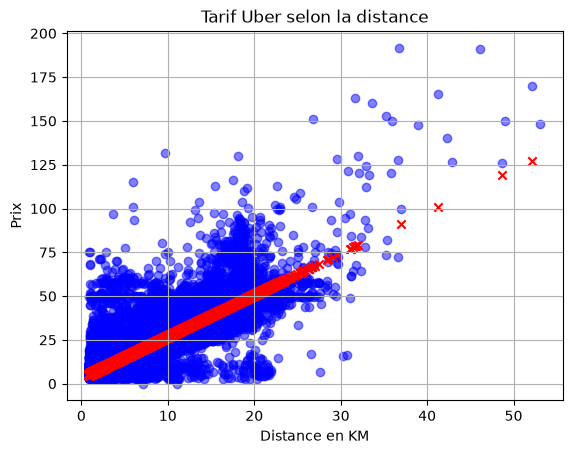

In [78]:
# visualisation

plt.scatter(X['distance_km'], Y, alpha=0.5, color='blue')
plt.scatter(X_test['distance_km'],y_pred,color='red',marker='x')
plt.xlabel('Distance en KM')
plt.ylabel('Prix')
plt.title('Tarif Uber selon la distance')
plt.grid(True)
plt.show()

Évaluation du modèle

In [79]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print('MAE =', mae)
print('RMSE =', rmse)
print('R² =', r2)

MAE = 2.361327922472657
RMSE = 4.076008149188463
R² = 0.8192443806247797


In [80]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

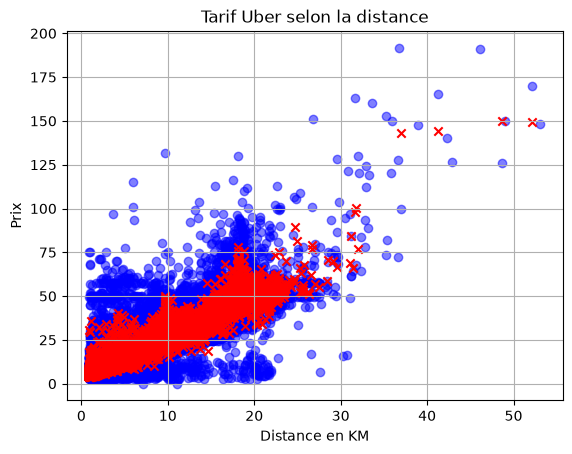

In [81]:
# visualisation

plt.scatter(X['distance_km'], Y, alpha=0.5, color='blue')
plt.scatter(X_test['distance_km'],y_pred_rf,color='red',marker='x')
plt.xlabel('Distance en KM')
plt.ylabel('Prix')
plt.title('Tarif Uber selon la distance')
plt.grid(True)
plt.show()

In [88]:
print(type(y_pred_rf))

<class 'numpy.ndarray'>


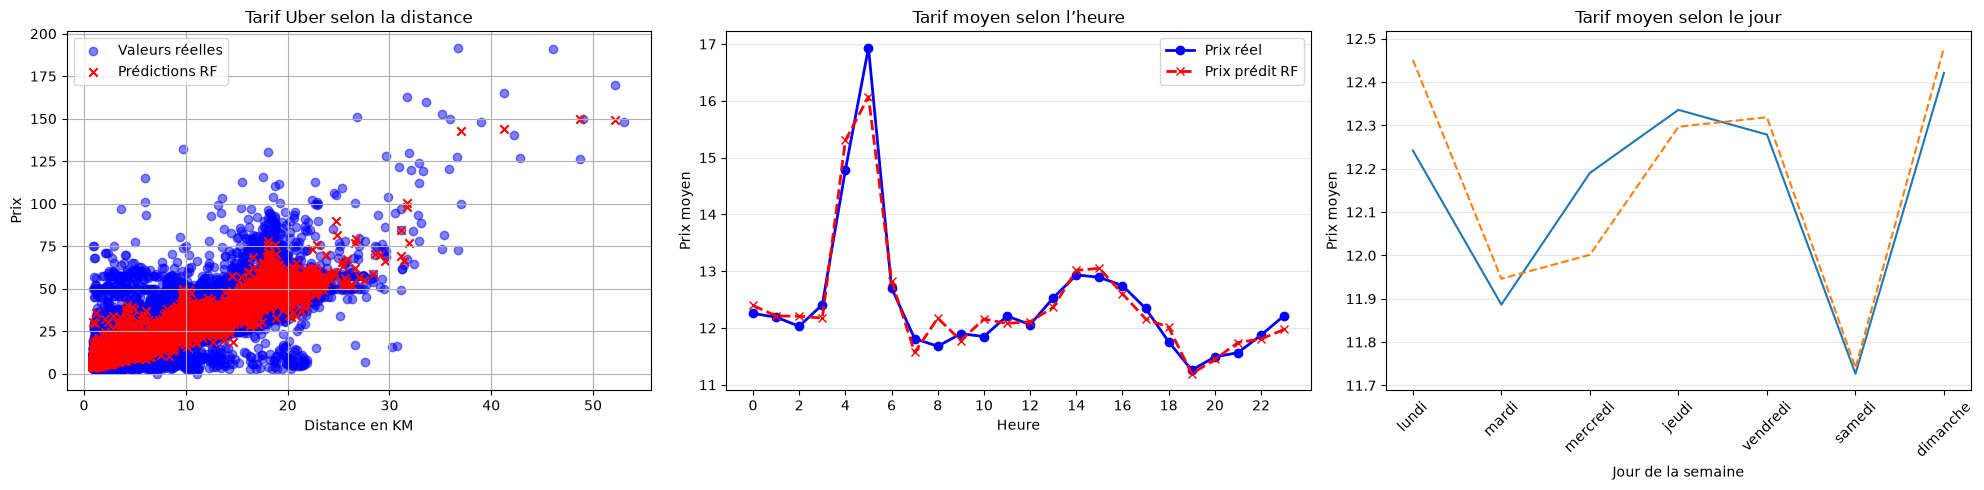

In [ ]:

jours_semaine = [
    'lundi', 'mardi', 'mercredi', 'jeudi',
    'vendredi', 'samedi', 'dimanche'
]


fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].scatter(
    X['distance_km'], Y,
    alpha=0.5, color='blue', label='Valeurs réelles'
)

axes[0].scatter(
    X_test['distance_km'], y_pred_rf,
    color='red', marker='x', label='Prédictions RF'
)

axes[0].set_xlabel('Distance en KM')
axes[0].set_ylabel('Prix')
axes[0].set_title('Tarif Uber selon la distance')
axes[0].grid(True)
axes[0].legend()



df_hour = pd.DataFrame({
    'hour': X['hour'].to_numpy(),
    'prix': Y.to_numpy() if hasattr(Y, 'to_numpy') else Y
})

prix_par_heure = df_hour.groupby('hour')['prix'].mean()

df_hour_pred_rf=pd.DataFrame({
    'hour':X_test['hour'].to_numpy(),
    'prix_prd_rf':y_pred_rf

})
prix_par_heure_pred_rf=df_hour_pred_rf.groupby('hour')['prix_prd_rf'].mean()


axes[1].plot(
    prix_par_heure.index,
    prix_par_heure.values,
    color='blue',
    linewidth=2,
    marker='o',
    label='Prix réel'
)

axes[1].plot(
    prix_par_heure_pred_rf.index,
    prix_par_heure_pred_rf.values,
    color='red',
    linewidth=2,
    marker='x',
    linestyle='--',
    label='Prix prédit RF'
)

axes[1].set_xlabel('Heure')
axes[1].set_ylabel('Prix moyen')
axes[1].set_title('Tarif moyen selon l’heure')
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend()


df_day = pd.DataFrame({
    'day_of_week': X['day_of_week'].to_numpy(),
    'prix': Y.to_numpy() if hasattr(Y, 'to_numpy') else Y
})

df_day_pred = pd.DataFrame({
    'day_of_week': X_test['day_of_week'].to_numpy(),
    'prix_prd_rf':y_pred_rf
})

prix_par_jour = df_day.groupby('day_of_week')['prix'].mean()
prix_par_jour_prd = df_day_pred.groupby('day_of_week')['prix_prd_rf'].mean()

prix_par_jour = prix_par_jour.reindex(range(7))
prix_par_jour_prd = prix_par_jour_prd.reindex(range(7))

axes[2].plot(jours_semaine, prix_par_jour.values)
axes[2].plot(jours_semaine,prix_par_jour_prd.values,linestyle='--')
axes[2].set_xlabel('Jour de la semaine')
axes[2].set_ylabel('Prix moyen')
axes[2].set_title('Tarif moyen selon le jour')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()